In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_ollama import ChatOllama
llm=ChatOllama(model="llama3.1:8b")
from langgraph.checkpoint.memory import MemorySaver



/Users/ryankhurana/Desktop/langgraph2/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
def chat_node(state: ChatState):
    # take user query from state
    messages = state['messages']
    # send to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response]}



In [4]:
graph = StateGraph(ChatState)
checkpointer = MemorySaver()

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

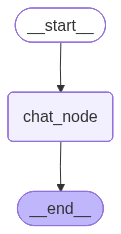

In [5]:
chatbot

In [7]:

initial_state = {
    
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
thread_id='1'# thread_id  identifies a conversation thread, allowing the chatbot to maintain context across multiple interactions. By using the same thread_id for subsequent messages, the chatbot can recall previous messages in the conversation and provide more coherent and contextually relevant responses.
while True:
    user_input = input("Type your message: ")

    print("User:", user_input)

    if user_input.strip().lower() in ["exit", "quit", "bye"]:
        print("GoodBye!")
        break
    config={
        'configurable':{'thread_id':thread_id}
    }

    response = chatbot.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )

    print("AI:", response["messages"][-1].content)

User: HI
AI: How's it going? Is there something I can help you with or would you like to chat?
User: a=10+@
AI: It looks like you're using the `@` symbol to represent a variable, but I'll assume it's just a simple arithmetic expression.

The result of `10 + @` would depend on the value of `@`. Could you please tell me what you think `@` should be equal to, or would you like me to make an assumption?
User: a=10+2
AI: Now we have a simple arithmetic expression!

If we evaluate the expression `a = 10 + 2`, we get:

`a = 12`

So, `a` is now equal to 12.
User: a+=12
AI: Now we have an augmented assignment!

If we evaluate the expression `a += 12`, we'll add 12 to the current value of `a`, which is 12.

`a = 12 + 12`
`a = 24`

So, `a` is now equal to 24.
User: a*a
AI: Now we have a multiplication expression!

If we evaluate the expression `a * a`, we'll multiply the current value of `a` (which is 24) by itself.

`a * a = 24 * 24`
`a * a = 576`

So, `a * a` is now equal to 576.
User: goodbye


In [ ]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='HI', additional_kwargs={}, response_metadata={}, id='cd92d10f-7504-43a4-85cd-9343abb35182'), AIMessage(content="How's it going? Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-03-13T01:21:10.710778Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8651384084, 'load_duration': 4005897625, 'prompt_eval_count': 11, 'prompt_eval_duration': 3501289834, 'eval_count': 21, 'eval_duration': 1135385875, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019ce4c8-5c63-77f3-83fe-f78b54230cee-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 21, 'total_tokens': 32}), HumanMessage(content='a=10+@', additional_kwargs={}, response_metadata={}, id='966f53c4-1543-4baf-8683-062da46fd191'), AIMessage(content="It looks like you're using the `@` symbol to repr